## Идея решения

Задача оценивается по `Precision при Recall >= 70%`, поэтому главная цель — получить **хорошее ранжирование cookie по вероятности бота**, а не подобрать фиксированный порог.

Я использую только события, попавшие в строгое окно:

`window_start_ts <= event_ts < window_end_ts`.

Признаки разделены на несколько групп:

1. **Объём и разнообразие**: число событий, объявлений, категорий, локаций, запросов, типов событий.
2. **Структура поведения**: доли разных типов событий, повторные просмотры, энтропия распределений.
3. **Время**: длительность активности, интервалы между событиями, число активных минут/часов, burstiness, число сессий, доля ночных/выходных событий.
4. **Последовательности**: нормированные частоты переходов между типами событий.
5. **Поиск и контент**: длины поисковых запросов, страницы выдачи, разнообразие объектов.
6. **Курсор**: наличие и интенсивность движения указателя.
7. **User-Agent**: наиболее частый UA и простые локальные признаки из него (ОС, браузер, headless/bot-like маркеры, мобильность).
8. **Техническое качество данных**: доля дубликатов.

Модель — ансамбль нескольких `LightGBM` с небольшим числом листьев. Никаких внешних API и LLM не используется.

### Валидация

В train есть временной сдвиг: train заканчивается 19 апреля, test начинается 20 апреля. Поэтому основная валидация — временная, а не случайный split.

Для выбора подхода я дополнительно проверил три последовательных временных фолда. Это ближе к реальному сценарию, где модель обучается на прошлом и применяется к будущему.

Важно: **порог в notebook не подбирается для submission**. В submission сохраняются непрерывные `score` от 0 до 1; порог перебирает проверяющая система.


In [1]:
import os
import re
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from lightgbm import LGBMClassifier, early_stopping

SEED = 42
np.random.seed(SEED)

# Запускать notebook можно из корня проекта, где лежат data/ и metric.py.
DATA_DIR = "data"

train = pd.read_csv(
    f"{DATA_DIR}/train.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
test = pd.read_csv(
    f"{DATA_DIR}/test.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
events = pd.read_csv(
    f"{DATA_DIR}/events.csv.gz",
    parse_dates=["event_ts"],
)

# Официальная реализация метрики дана организаторами в metric.py.
sys.path.insert(0, ".")
from metric import precision_at_recall, recall_at_fpr

print("train:", train.shape)
print("test :", test.shape)
print("events:", events.shape)
print("bot rate:", round(train.target.mean(), 4))


train: (11091, 5)
test : (4909, 4)
events: (328905, 14)
bot rate: 0.0811


## 1. Первичная проверка данных

Сначала проверяем типы, распределения событий и дубликаты. Дубликаты не удаляем автоматически: повтор события может быть частью поведения, а отдельный признак дубликатов позволит модели самой определить, полезен ли этот сигнал.


In [2]:
print(events.event_name.value_counts())
print("\nMissing values:")
print(events.isna().mean().sort_values(ascending=False).round(3))
print("\nExact duplicate rows:", events.duplicated().sum())
print("Duplicate rate:", round(events.duplicated().mean(), 4))


event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64

Missing values:
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
seller_type      0.407
item_id          0.348
item_category    0.100
item_location    0.072
user_agent       0.000
platform         0.000
event_ts         0.000
cookie_id        0.000
event_name       0.000
eid              0.000
dtype: float64

Exact duplicate rows: 4863
Duplicate rate: 0.0148


## Визуализация 1. Баланс классов

Перед обучением важно увидеть масштаб дисбаланса. Официальная метрика ориентирована на высокую полноту, поэтому одной accuracy здесь недостаточно.


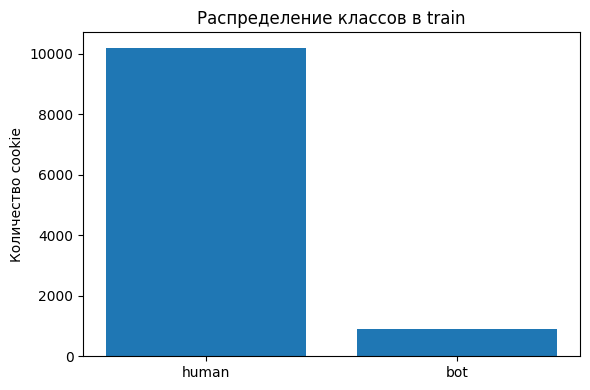

Доля ботов: 8.11%
Вывод: классы заметно несбалансированы; поэтому PR-AUC и Precision@Recall информативнее одной accuracy.


In [3]:
# Доли классов train.
class_counts = train.target.value_counts().sort_index()
class_names = ["human", "bot"]

plt.figure(figsize=(6, 4))
plt.bar(class_names, [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Распределение классов в train")
plt.ylabel("Количество cookie")
plt.tight_layout()
plt.show()

bot_share = train.target.mean()
print(f"Доля ботов: {bot_share:.2%}")
print("Вывод: классы заметно несбалансированы; поэтому PR-AUC и Precision@Recall информативнее одной accuracy.")


## 2. Ограничение событий суточным окном

Это принципиальное место. Для каждой cookie используются только события, удовлетворяющие условию из задания. События до начала окна и после его окончания не попадают ни в один признак.

Сначала объединяем train и test metadata, затем один раз фильтруем общий поток событий.


In [4]:
meta = pd.concat(
    [train.assign(_split="train"), test.assign(_split="test")],
    ignore_index=True,
)

def events_in_window(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    m = meta[["cookie_id", "window_start_ts", "window_end_ts"]]
    x = events.merge(m, on="cookie_id", how="inner")
    return x[
        (x.event_ts >= x.window_start_ts)
        & (x.event_ts < x.window_end_ts)
    ].copy()

evw = events_in_window(events, meta)

print("events inside windows:", len(evw))
print("cookies covered:", evw.cookie_id.nunique(), "/", len(meta))


events inside windows: 288126
cookies covered: 16000 / 16000


## 3. Построение признаков

Ниже одна функция строит все признаки. Важный принцип: она получает уже отфильтрованные события `evw`, поэтому случайно использовать информацию после `window_end_ts` внутри признаков невозможно.

Для категориальных полей мы используем простые агрегаты (например, наиболее частую платформу или категорию), а не запоминаем `cookie_id` как признак. Это уменьшает риск бессмысленного запоминания идентификаторов.


In [5]:

def build_features(evw: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    out = meta[
        ["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]
    ].copy()

    # ---- Базовые агрегаты ----
    g = evw.groupby("cookie_id", sort=False)
    agg = g.agg(
        n_events=("event_name", "size"),
        n_event_types=("event_name", "nunique"),
        n_items=("item_id", "nunique"),
        n_categories=("item_category", "nunique"),
        n_locations=("item_location", "nunique"),
        n_sellers=("seller_type", "nunique"),
        n_queries=("search_query", "nunique"),
        n_ua=("user_agent", "nunique"),
        n_platforms=("platform", "nunique"),
        first_event=("event_ts", "min"),
        last_event=("event_ts", "max"),
        n_pointer=("pointer_x", "count"),
        n_search_pages=("search_page", "count"),
        mean_search_page=("search_page", "mean"),
        max_search_page=("search_page", "max"),
    ).reset_index()
    out = out.merge(agg, on="cookie_id", how="left")

    # ---- Число и доля каждого типа события ----
    counts = pd.crosstab(evw.cookie_id, evw.event_name)
    counts.columns = [
        "cnt_event_" + re.sub(r"[^a-z0-9]+", "_", str(c))
        for c in counts.columns
    ]
    out = out.merge(counts.reset_index(), on="cookie_id", how="left")

    event_cols = [c for c in out.columns if c.startswith("cnt_event_")]
    for c in event_cols:
        out[c + "_rate"] = out[c] / out["n_events"]

    # Разнообразие относительно объёма трафика.
    for c in ["n_items", "n_categories", "n_locations", "n_sellers",
              "n_queries", "n_ua"]:
        out[c + "_per_event"] = out[c] / out["n_events"]

    # ---- Длительность и интенсивность ----
    out["active_span_sec"] = (
        out.last_event - out.first_event
    ).dt.total_seconds()
    out["events_per_min"] = out.n_events / (out.active_span_sec / 60 + 1)
    out["events_per_hour"] = out.n_events / (out.active_span_sec / 3600 + 1)

    # ---- Временная структура ----
    z = evw[["cookie_id", "event_ts"]].copy()
    z["minute"] = z.event_ts.dt.floor("min")
    z["hour"] = z.event_ts.dt.hour
    z["dow"] = z.event_ts.dt.dayofweek

    active = z.groupby("cookie_id").agg(
        active_hours=("hour", "nunique"),
        active_minutes=("minute", "nunique"),
    ).reset_index()
    out = out.merge(active, on="cookie_id", how="left")

    def entropy_feature(frame, col):
        vc = frame.groupby(["cookie_id", col]).size()
        return vc.groupby(level=0).apply(
            lambda x: entropy(x.values / x.values.sum())
        ).rename(col + "_entropy").reset_index()

    out = out.merge(entropy_feature(z, "hour"), on="cookie_id", how="left")
    out = out.merge(entropy_feature(z, "dow"), on="cookie_id", how="left")

    # Интервалы между событиями.
    z = z.sort_values(["cookie_id", "event_ts"])
    z["gap"] = z.groupby("cookie_id").event_ts.diff().dt.total_seconds()
    gaps = z.dropna(subset=["gap"])
    gg = gaps.groupby("cookie_id").gap.agg(
        gap_median_sec="median",
        gap_mean_sec="mean",
        gap_p10_sec=lambda x: x.quantile(.1),
        gap_p90_sec=lambda x: x.quantile(.9),
        zero_gap_frac=lambda x: (x == 0).mean(),
    ).reset_index()
    out = out.merge(gg, on="cookie_id", how="left")

    # Burstiness: сколько событий происходит в одной минуте.
    minute_counts = z.groupby(["cookie_id", "minute"]).size()
    burst = minute_counts.groupby(level=0).agg(
        max_per_min="max",
        mean_per_min="mean",
        std_per_min="std",
    ).reset_index()
    burst = burst.merge(
        minute_counts.groupby(level=0).quantile(.9).rename("p90_per_min").reset_index(),
        on="cookie_id",
    )
    burst = burst.merge(
        minute_counts.groupby(level=0).quantile(.99).rename("p99_per_min").reset_index(),
        on="cookie_id",
    )
    out = out.merge(burst, on="cookie_id", how="left")

    # ---- Поисковые запросы ----
    q = evw.loc[
        evw.search_query.notna(), ["cookie_id", "search_query"]
    ].copy()
    if len(q):
        q["qlen"] = q.search_query.astype(str).str.len()
        qg = q.groupby("cookie_id").qlen.agg(
            query_len_mean="mean",
            query_len_max="max",
        ).reset_index()
        out = out.merge(qg, on="cookie_id", how="left")

    # ---- Курсор ----
    ptr = evw.dropna(
        subset=["pointer_x", "pointer_y"]
    )[["cookie_id", "event_ts", "pointer_x", "pointer_y"]].sort_values(
        ["cookie_id", "event_ts"]
    ).copy()

    if len(ptr):
        ptr["dx"] = ptr.groupby("cookie_id").pointer_x.diff()
        ptr["dy"] = ptr.groupby("cookie_id").pointer_y.diff()
        ptr["dist"] = np.hypot(
            ptr.dx.fillna(0), ptr.dy.fillna(0)
        )
        pg = ptr.groupby("cookie_id").agg(
            pointer_unique_x=("pointer_x", "nunique"),
            pointer_unique_y=("pointer_y", "nunique"),
            pointer_dist_total=("dist", "sum"),
            pointer_dist_mean=("dist", "mean"),
            pointer_dist_p90=("dist", lambda x: x.quantile(.9)),
            pointer_zero_move_frac=("dist", lambda x: (x == 0).mean()),
        ).reset_index()
        out = out.merge(pg, on="cookie_id", how="left")

    # ---- Дубликаты ----
    exact = evw.groupby("cookie_id").apply(
        lambda x: x.duplicated().sum(),
        include_groups=False,
    ).rename("exact_dup_events").reset_index()
    out = out.merge(exact, on="cookie_id", how="left")
    out["dup_rate"] = out.exact_dup_events / out.n_events

    # ---- Самый частый User-Agent ----
    uac = (
        evw.groupby(["cookie_id", "user_agent"], dropna=False)
        .size()
        .rename("ua_freq")
        .reset_index()
        .sort_values(["cookie_id", "ua_freq"], ascending=[True, False])
        .drop_duplicates("cookie_id")
    )
    uaf = uac.rename(
        columns={"user_agent": "ua_mode", "ua_freq": "ua_mode_freq"}
    )[["cookie_id", "ua_mode", "ua_mode_freq"]]
    out = out.merge(uaf, on="cookie_id", how="left")

    # ---- Последовательности событий ----
    seq = evw[
        ["cookie_id", "event_ts", "event_name"]
    ].sort_values(["cookie_id", "event_ts"]).copy()
    seq["next_event"] = seq.groupby("cookie_id").event_name.shift(-1)
    trn = seq.dropna(subset=["next_event"]).groupby(
        ["cookie_id", "event_name", "next_event"]
    ).size()

    tg = trn.groupby(level=0).agg(
        transition_nunique="size",
        transition_total="sum",
        transition_max="max",
    ).reset_index()
    out = out.merge(tg, on="cookie_id", how="left")
    out["transition_max_rate"] = out.transition_max / out.transition_total

    # Возраст cookie к началу наблюдаемого окна.
    out["cookie_age_hours"] = (
        out.window_start_ts - out.cookie_created_at
    ).dt.total_seconds() / 3600

    return out.drop(
        columns=[
            "first_event", "last_event",
            "cookie_created_at", "window_start_ts", "window_end_ts",
        ]
    )


def add_behavior_features(X: pd.DataFrame, e: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    # Энтропия и повторяемость отдельных потоков.
    for col, prefix in [
        ("item_id", "item"),
        ("item_category", "category"),
        ("item_location", "location"),
        ("search_query", "query"),
        ("event_name", "event"),
    ]:
        z = e.dropna(subset=[col]).groupby(["cookie_id", col]).size()
        ent = z.groupby(level=0).apply(
            lambda x: entropy(x.values / x.values.sum())
        ).rename(prefix + "_entropy").reset_index()
        mx = z.groupby(level=0).max().rename(
            prefix + "_max_repeats"
        ).reset_index()
        X = X.merge(ent, on="cookie_id", how="left")
        X = X.merge(mx, on="cookie_id", how="left")

    # Повторы объявлений.
    itemev = e[e.item_id.notna()].copy()
    ir = itemev.groupby("cookie_id").agg(
        item_rows=("item_id", "size"),
        item_unique=("item_id", "nunique"),
    ).reset_index()
    ir["item_repeat_rate"] = (
        1 - ir.item_unique / ir.item_rows.clip(lower=1)
    )
    X = X.merge(ir, on="cookie_id", how="left")

    # Сессии: новый сеанс после простоя более 30 минут.
    z = e[["cookie_id", "event_ts"]].sort_values(
        ["cookie_id", "event_ts"]
    ).copy()
    z["gap"] = z.groupby("cookie_id").event_ts.diff().dt.total_seconds()
    z["new_session"] = (z.gap.fillna(1e9) > 1800).astype(int)

    sess = z.groupby("cookie_id").agg(
        n_sessions=("new_session", "sum"),
        max_gap_sec=("gap", "max"),
        night_frac=("event_ts", lambda x: (
            ((x.dt.hour < 7) | (x.dt.hour >= 23)).mean()
        )),
        weekend_frac=("event_ts", lambda x: (
            (x.dt.dayofweek >= 5).mean()
        )),
        first_hour=("event_ts", lambda x: x.iloc[0].hour),
        last_hour=("event_ts", lambda x: x.iloc[-1].hour),
    ).reset_index()
    X = X.merge(sess, on="cookie_id", how="left")

    # Профиль активности по часам суток.
    hz = (
        e.assign(_hour=e.event_ts.dt.hour)
        .groupby(["cookie_id", "_hour"]).size()
        .unstack(fill_value=0)
        .reindex(columns=range(24), fill_value=0)
    )
    hz.columns = [f"events_hour_{i}" for i in hz.columns]
    X = X.merge(hz.reset_index(), on="cookie_id", how="left")

    # Полная матрица переходов между типами событий.
    seq = e[
        ["cookie_id", "event_ts", "event_name"]
    ].sort_values(["cookie_id", "event_ts"]).copy()
    seq["next_event"] = seq.groupby("cookie_id").event_name.shift(-1)
    seq = seq.dropna(subset=["next_event"])

    names = sorted(e.event_name.unique())
    trn = seq.groupby(
        ["cookie_id", "event_name", "next_event"]
    ).size().unstack([1, 2], fill_value=0)
    trn = trn.reindex(
        columns=pd.MultiIndex.from_product([names, names]),
        fill_value=0,
    )
    trn.columns = [
        f"trans_{a}_to_{b}" for a, b in trn.columns
    ]
    trn = trn.div(
        trn.sum(axis=1).replace(0, 1), axis=0
    ).reset_index()
    X = X.merge(trn, on="cookie_id", how="left")

    return X


def add_modes(X: pd.DataFrame, e: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    for col, prefix in [
        ("platform", "platform_mode"),
        ("item_category", "category_mode"),
        ("item_location", "location_mode"),
        ("seller_type", "seller_mode"),
    ]:
        vc = (
            e.groupby(["cookie_id", col], dropna=False)
            .size().rename("freq").reset_index()
            .sort_values(["cookie_id", "freq"], ascending=[True, False])
            .drop_duplicates("cookie_id")
        )
        X = X.merge(
            vc[["cookie_id", col]].rename(columns={col: prefix}),
            on="cookie_id", how="left",
        )
    return X


def add_ua_parsed(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    s = X.ua_mode.fillna("").astype(str).str.lower()

    X["ua_len"] = s.str.len()
    X["ua_headless"] = s.str.contains("headless", regex=False).astype(int)
    X["ua_botword"] = s.str.contains(
        r"bot|crawler|spider|scraper|selenium|playwright|phantom",
        regex=True,
    ).astype(int)
    X["ua_mobile"] = s.str.contains(
        r"mobile|android|iphone|ipad", regex=True
    ).astype(int)

    X["ua_os"] = np.select(
        [
            s.str.contains("windows"),
            s.str.contains("linux"),
            s.str.contains("macintosh|mac os"),
            s.str.contains("android"),
            s.str.contains("iphone|ipad"),
        ],
        ["windows", "linux", "mac", "android", "ios"],
        default="other",
    )

    X["ua_browser"] = np.select(
        [
            s.str.contains("headlesschrome"),
            s.str.contains("yabrowser"),
            s.str.contains("chrome/"),
            s.str.contains("firefox/"),
            s.str.contains("safari/"),
            s.str.contains("edg/"),
        ],
        ["headlesschrome", "yandex", "chrome", "firefox",
         "safari", "edge"],
        default="other",
    )

    X["ua_major"] = pd.to_numeric(
        s.str.extract(
            r"(?:chrome|firefox|version|yabrowser|edg)/(\d+)",
            expand=False,
        ),
        errors="coerce",
    ).fillna(-1)

    return X


## Визуализация 2. Интенсивность поведения

Сравним число событий на cookie для людей и ботов. Для такого счётчика полезна логарифмическая шкала: несколько очень активных пользователей иначе сожмут основную массу наблюдений.


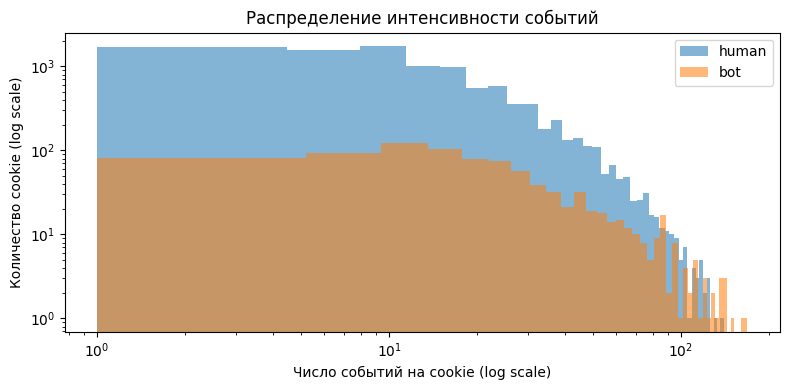

Медиана событий: human=12.0, bot=20.0
Вывод: различия в объёме активности дают полезный baseline-сигнал, но одной интенсивности недостаточно — поэтому добавлены временные и поведенческие признаки.


In [6]:
# Для визуализации не зависим от матрицы X: агрегируем события напрямую.
# Это делает блок самостоятельным и позволяет запускать его сразу после подготовки evw.
plot_df = (
    evw.groupby("cookie_id").size().rename("n_events").reset_index()
    .merge(train[["cookie_id", "target"]], on="cookie_id", how="inner")
)

plt.figure(figsize=(8, 4))
for label, name in [(0, "human"), (1, "bot")]:
    vals = plot_df.loc[plot_df.target == label, "n_events"].clip(lower=1)
    plt.hist(vals, bins=40, alpha=0.55, label=name, log=True)
plt.xscale("log")
plt.xlabel("Число событий на cookie (log scale)")
plt.ylabel("Количество cookie (log scale)")
plt.title("Распределение интенсивности событий")
plt.legend()
plt.tight_layout()
plt.show()

med = plot_df.groupby("target").n_events.median()
print(f"Медиана событий: human={med.get(0, np.nan):.1f}, bot={med.get(1, np.nan):.1f}")
print("Вывод: различия в объёме активности дают полезный baseline-сигнал, но одной интенсивности недостаточно — поэтому добавлены временные и поведенческие признаки.")


## Визуализация 3. Временной профиль событий

Боты могут отличаться не только количеством событий, но и тем, как они распределены во времени. Здесь смотрим среднюю долю событий каждого часа отдельно для двух классов.


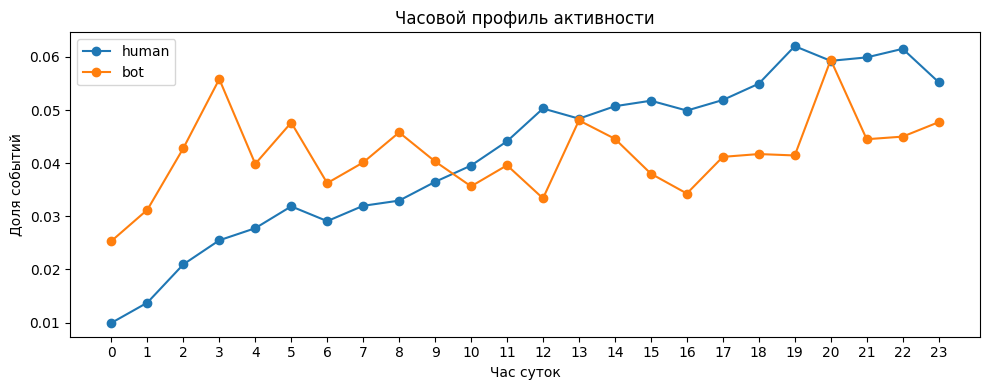

Пиковые часы:
 target  hour    share
      0    19 0.062031
      1    20 0.059456
Вывод: временной профиль потенциально несёт дополнительный сигнал, поэтому в модели используются active_hours, active_minutes, entropy и интервалы между событиями.


In [7]:
hour_df = evw.copy()
hour_df["hour"] = hour_df.event_ts.dt.hour
profile = hour_df.groupby(["cookie_id", "hour"]).size().rename("n").reset_index()
profile = profile.merge(train[["cookie_id", "target"]], on="cookie_id", how="inner")
profile = profile.groupby(["target", "hour"]).n.sum().reset_index()
totals = profile.groupby("target").n.sum()
profile["share"] = profile.apply(lambda r: r.n / totals.loc[r.target], axis=1)

plt.figure(figsize=(10, 4))
for label, name in [(0, "human"), (1, "bot")]:
    z = profile[profile.target == label].set_index("hour").reindex(range(24), fill_value=0)
    plt.plot(z.index, z.share, marker="o", label=name)
plt.xticks(range(24))
plt.xlabel("Час суток")
plt.ylabel("Доля событий")
plt.title("Часовой профиль активности")
plt.legend()
plt.tight_layout()
plt.show()

peak = profile.loc[profile.groupby("target").share.idxmax(), ["target", "hour", "share"]]
print("Пиковые часы:")
print(peak.to_string(index=False))
print("Вывод: временной профиль потенциально несёт дополнительный сигнал, поэтому в модели используются active_hours, active_minutes, entropy и интервалы между событиями.")


In [8]:
t0 = time.time()

X = build_features(evw, meta)
X = add_modes(X, evw)
X = add_behavior_features(X, evw)
X = add_ua_parsed(X)

# В итоговую модель cookie_id не передаём: это идентификатор, а не поведенческий признак.
assert X.cookie_id.is_unique
print("feature matrix:", X.shape)
print("feature build time:", round(time.time() - t0, 1), "sec")


feature matrix: (16000, 207)
feature build time: 53.8 sec


## 4. Baseline

Для сравнения повторяем простую идею quickstart: только количество событий и уникальных объявлений + Random Forest.

Здесь важна не абсолютная величина baseline, а наличие понятной точки отсчёта перед добавлением поведенческих признаков.


In [9]:
y = train.target.to_numpy()

# Валидационная маска относится только к train.
# Приводим её к позиционной numpy-маске, чтобы pandas не пытался
# выровнять индексы X_model и is_valid по меткам.
is_valid = (
    train.window_start_ts >= pd.Timestamp("2026-04-17")
).to_numpy(dtype=bool)

# X содержит train + test; baseline и основной LightGBM обучаются только на train.
# LightGBM в этой версии принимает только числовые/bool признаки, поэтому
# все строковые/категориальные признаки кодируем одинаково на полном X.
X_model = X.drop(columns=["cookie_id"]).copy()

for c in X_model.columns:
    if pd.api.types.is_object_dtype(X_model[c]) or pd.api.types.is_categorical_dtype(X_model[c]):
        X_model[c] = pd.Categorical(X_model[c]).codes.astype(np.float32)
    elif pd.api.types.is_datetime64_any_dtype(X_model[c]):
        X_model[c] = X_model[c].astype("int64") / 1e9

X_train_model = X_model.iloc[:len(train)].reset_index(drop=True)

baseline_cols = ["n_events", "n_items"]

assert len(X_train_model) == len(y) == len(is_valid)

baseline = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=0,
    n_jobs=-1,
)
baseline.fit(
    X_train_model.iloc[~is_valid][baseline_cols],
    y[~is_valid],
)
p_base = baseline.predict_proba(
    X_train_model.iloc[is_valid][baseline_cols]
)[:, 1]

print("Baseline P@R>=0.7:", round(
    precision_at_recall(y[is_valid], p_base), 4
))
print("Baseline PR-AUC:", round(
    average_precision_score(y[is_valid], p_base), 4
))
print("Baseline ROC-AUC:", round(
    roc_auc_score(y[is_valid], p_base), 4
))


C:\Users\User\AppData\Local\Temp\ipykernel_12008\4149495706.py:16: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(X_model[c]) or pd.api.types.is_categorical_dtype(X_model[c]):


Baseline P@R>=0.7: 0.1025
Baseline PR-AUC: 0.1746
Baseline ROC-AUC: 0.6074


## 5. Улучшенная модель

Используем LightGBM. Малое число листьев (`num_leaves=15`) выбрано по временной валидации: оно оказалось стабильнее более сложных деревьев на малом положительном классе.

Категориальные агрегаты здесь не используются как порядковые величины по смыслу — они лишь кодируются одинаково для train/test. Важнейшие сигналы приходят от числовых поведенческих признаков, а User-Agent представлен также разложенными признаками.

Early stopping используется только на validation; для финального обучения ниже число итераций фиксируется примерно на уровне, который показали временные фолды.


In [10]:
valid_X = X_model.iloc[:len(train)].reset_index(drop=True).copy()
valid_y = y

# Блок самодостаточный: даже если предыдущие ячейки были запущены
# в старом состоянии, LightGBM получает только числовые признаки.
for c in valid_X.columns:
    if pd.api.types.is_object_dtype(valid_X[c]) or pd.api.types.is_string_dtype(valid_X[c]):
        valid_X[c] = pd.Categorical(valid_X[c]).codes.astype(np.float32)
    elif pd.api.types.is_categorical_dtype(valid_X[c]):
        valid_X[c] = valid_X[c].cat.codes.astype(np.float32)
    elif pd.api.types.is_datetime64_any_dtype(valid_X[c]):
        valid_X[c] = valid_X[c].astype("int64") / 1e9

# Последний контроль: никаких object/string/category/datetime в X.
bad_cols = [c for c in valid_X.columns if not (
    pd.api.types.is_numeric_dtype(valid_X[c]) or pd.api.types.is_bool_dtype(valid_X[c])
)]
assert not bad_cols, f"Non-numeric columns remain: {bad_cols}"

valid_mask = np.asarray(is_valid, dtype=bool)
assert len(valid_X) == len(valid_y) == len(valid_mask)

model = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    num_leaves=15,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=5,
    min_child_samples=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

model.fit(
    valid_X.iloc[~valid_mask],
    valid_y[~valid_mask],
    eval_set=[(valid_X.iloc[valid_mask], valid_y[valid_mask])],
    callbacks=[early_stopping(80, verbose=False)],
)

p_valid = model.predict_proba(valid_X.iloc[valid_mask])[:, 1]

print("best iteration:", model.best_iteration_)
print("P@R>=0.7:", round(
    precision_at_recall(valid_y[valid_mask], p_valid), 4
))
print("PR-AUC:", round(
    average_precision_score(valid_y[valid_mask], p_valid), 4
))
print("ROC-AUC:", round(
    roc_auc_score(valid_y[valid_mask], p_valid), 4
))
print("Recall @ FPR<=1%:", round(
    recall_at_fpr(valid_y[valid_mask], p_valid), 4
))


C:\Users\User\AppData\Local\Temp\ipykernel_12008\3042412834.py:9: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(valid_X[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\3042412834.py:9: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(valid_X[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\3042412834.py:9: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(valid_X[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\3042412834.py:9: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  

best iteration: 530
P@R>=0.7: 0.655
PR-AUC: 0.7458
ROC-AUC: 0.9234
Recall @ FPR<=1%: 0.525


## Визуализация 4. Какие признаки использует модель

Feature importance помогает проверить, что модель опирается не на один случайный признак, а на комбинацию поведенческих характеристик. Это не причинная интерпретация: важность показывает вклад в предсказательную модель.


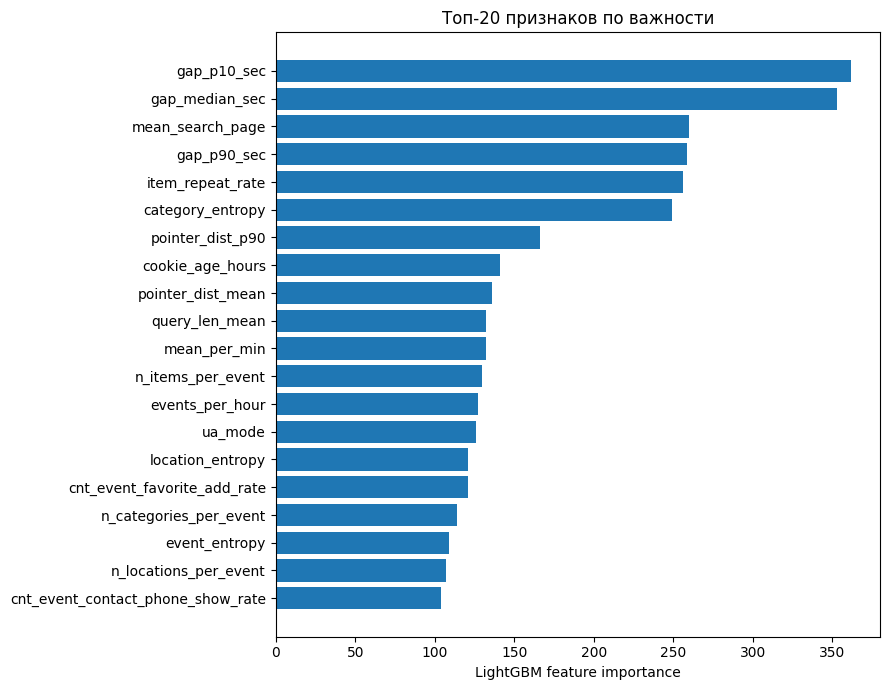

Топ-10:
          feature  importance
      gap_p10_sec         362
   gap_median_sec         353
 mean_search_page         260
      gap_p90_sec         259
 item_repeat_rate         256
 category_entropy         249
 pointer_dist_p90         166
 cookie_age_hours         141
pointer_dist_mean         136
     mean_per_min         132
Вывод: модель использует совокупность признаков объёма, временной структуры и поведения, а не cookie_id или ручную разметку.


In [11]:
importance = pd.DataFrame({
    "feature": valid_X.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).head(20).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(importance.feature, importance.importance)
plt.xlabel("LightGBM feature importance")
plt.title("Топ-20 признаков по важности")
plt.tight_layout()
plt.show()

print("Топ-10:")
print(importance.sort_values("importance", ascending=False).head(10).to_string(index=False))
print("Вывод: модель использует совокупность признаков объёма, временной структуры и поведения, а не cookie_id или ручную разметку.")


## 6. Дополнительная временная проверка

Последний holdout может быть случайным. Поэтому проверяем тот же пайплайн на нескольких последовательных временных фолдах.

Ни один признак не использует target, а в каждом fold модель видит только более ранние дни. Это также помогает обнаружить сильную зависимость от конкретного периода.


In [12]:
# Используем отдельную числовую копию, чтобы ячейка не зависела
# от состояния X_model из предыдущих запусков.
fold_X = X_model.iloc[:len(train)].reset_index(drop=True).copy()
for c in fold_X.columns:
    if pd.api.types.is_object_dtype(fold_X[c]) or pd.api.types.is_string_dtype(fold_X[c]):
        fold_X[c] = pd.Categorical(fold_X[c]).codes.astype(np.float32)
    elif pd.api.types.is_categorical_dtype(fold_X[c]):
        fold_X[c] = fold_X[c].cat.codes.astype(np.float32)
    elif pd.api.types.is_datetime64_any_dtype(fold_X[c]):
        fold_X[c] = fold_X[c].astype("int64") / 1e9

folds = [
    ("2026-04-06", "2026-04-12", "2026-04-13", "2026-04-15"),
    ("2026-04-06", "2026-04-15", "2026-04-16", "2026-04-17"),
    ("2026-04-06", "2026-04-17", "2026-04-18", "2026-04-19"),
]

fold_results = []

for train_from, train_to, valid_from, valid_to in folds:
    tr_mask = train.window_start_ts.between(train_from, train_to).to_numpy(dtype=bool)
    va_mask = train.window_start_ts.between(valid_from, valid_to).to_numpy(dtype=bool)

    fold_model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.025,
        num_leaves=15,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=5,
        min_child_samples=30,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    fold_model.fit(
        fold_X.iloc[tr_mask],
        y[tr_mask],
        eval_set=[(fold_X.iloc[va_mask], y[va_mask])],
        callbacks=[early_stopping(80, verbose=False)],
    )

    p = fold_model.predict_proba(fold_X.iloc[va_mask])[:, 1]
    row = {
        "validation": f"{valid_from}..{valid_to}",
        "n": int(va_mask.sum()),
        "positives": int(y[va_mask].sum()),
        "best_iteration": int(fold_model.best_iteration_),
        "P@R>=0.7": precision_at_recall(y[va_mask], p),
        "PR-AUC": average_precision_score(y[va_mask], p),
        "ROC-AUC": roc_auc_score(y[va_mask], p),
    }
    fold_results.append(row)

pd.DataFrame(fold_results)


C:\Users\User\AppData\Local\Temp\ipykernel_12008\498799426.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(fold_X[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\498799426.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(fold_X[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\498799426.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(fold_X[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\498799426.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd

,validation,n,positives,best_iteration,P@R>=0.7,PR-AUC,ROC-AUC
0,2026-04-13..2026-04-15,2470,188,377,0.733333,0.778320,0.922474
1,2026-04-16..2026-04-17,1453,126,339,0.597315,0.705499,0.907513
2,2026-04-18..2026-04-19,1238,94,477,0.683673,0.760314,0.941768


## Визуализация 5. Стабильность по временным фолдам

Главная проверка обобщения здесь — не случайный split, а последовательные временные окна. Сравним Precision@Recall и PR-AUC между фолдами.


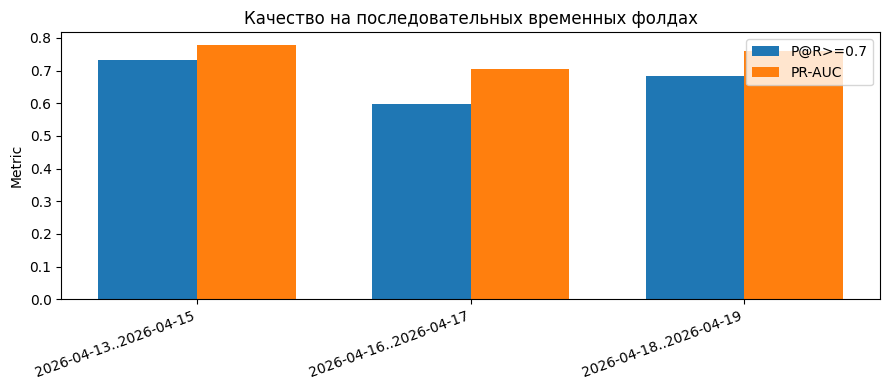

Средний P@R>=0.7: 0.6714
Средний PR-AUC: 0.7480
Разброс P@R>=0.7: 0.0562
Вывод: временные фолды показывают, насколько качество зависит от периода; это более реалистичная проверка для test, который идёт после train по времени.


In [13]:
fold_df = pd.DataFrame(fold_results)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(fold_df))
w = 0.36
ax.bar(x - w/2, fold_df["P@R>=0.7"], width=w, label="P@R>=0.7")
ax.bar(x + w/2, fold_df["PR-AUC"], width=w, label="PR-AUC")
ax.set_xticks(x)
ax.set_xticklabels(fold_df.validation, rotation=20, ha="right")
ax.set_ylabel("Metric")
ax.set_title("Качество на последовательных временных фолдах")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Средний P@R>=0.7: {fold_df['P@R>=0.7'].mean():.4f}")
print(f"Средний PR-AUC: {fold_df['PR-AUC'].mean():.4f}")
print(f"Разброс P@R>=0.7: {fold_df['P@R>=0.7'].std(ddof=0):.4f}")
print("Вывод: временные фолды показывают, насколько качество зависит от периода; это более реалистичная проверка для test, который идёт после train по времени.")


## 6.5. Итоговая интерпретация перед submission

На этом этапе связываем EDA и валидацию в одну гипотезу: боты должны отличаться не только объёмом трафика, но и регулярностью, временной структурой, повторяемостью действий и техническими характеристиками User-Agent.

Если временные фолды показывают сопоставимое качество, а feature importance распределена между несколькими группами признаков, это поддерживает выбранный feature-based подход. При этом локальная валидация не является гарантией результата на скрытом test.


## 7. Финальное обучение и submission

Тест начинается после последнего дня train, поэтому после выбора гиперпараметров обучаем несколько LightGBM на **всём train**.

Ансамбль усредняет вероятности трёх моделей с фиксированными seed и немного разным числом деревьев. Это уменьшает зависимость результата от одной случайной инициализации.

Порог здесь специально не фиксируется: проверяющая система сама перебирает пороги и считает официальный `Precision при Recall >= 70%`.


In [14]:
X_final = X.drop(columns=["cookie_id"]).copy()

# Единое кодирование категориальных признаков для train + test.
for c in X_final.columns:
    if pd.api.types.is_object_dtype(X_final[c]) or pd.api.types.is_string_dtype(X_final[c]):
        X_final[c] = pd.Categorical(X_final[c]).codes.astype(np.float32)
    elif pd.api.types.is_categorical_dtype(X_final[c]):
        X_final[c] = X_final[c].cat.codes.astype(np.float32)
    elif pd.api.types.is_datetime64_any_dtype(X_final[c]):
        X_final[c] = X_final[c].astype("int64") / 1e9

bad_cols = [c for c in X_final.columns if not (
    pd.api.types.is_numeric_dtype(X_final[c]) or pd.api.types.is_bool_dtype(X_final[c])
)]
assert not bad_cols, f"Non-numeric columns remain: {bad_cols}"

X_train = X_final.iloc[:len(train)].reset_index(drop=True)
X_test = X_final.iloc[len(train):].reset_index(drop=True)

predictions = []

for seed, n_estimators in [
    (42, 350),
    (123, 400),
    (2026, 450),
]:
    final_model = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.025,
        num_leaves=15,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=5,
        min_child_samples=30,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )
    final_model.fit(X_train, y)
    predictions.append(
        final_model.predict_proba(X_test)[:, 1]
    )

score = np.mean(predictions, axis=0)
score = np.clip(score, 0, 1)

submission = pd.DataFrame({
    "cookie_id": test.cookie_id,
    "score": score,
})

# Формальные проверки формата.
assert list(submission.columns) == ["cookie_id", "score"]
assert len(submission) == len(test)
assert submission.cookie_id.nunique() == len(test)
assert submission.score.notna().all()
assert submission.score.between(0, 1).all()
assert set(submission.cookie_id) == set(test.cookie_id)

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("\nSaved submission.csv:", submission.shape)


C:\Users\User\AppData\Local\Temp\ipykernel_12008\344871502.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(X_final[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\344871502.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(X_final[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\344871502.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(X_final[c]):
C:\Users\User\AppData\Local\Temp\ipykernel_12008\344871502.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif

             cookie_id     score
0  ck_315fb710a0e371e7  0.002914
1  ck_a76ee3b3e3e522fd  0.127670
2  ck_94c9a4d382689e82  0.084311
3  ck_8eaf9509ad9462a0  0.002731
4  ck_9a88a5a989cb5bc6  0.008139

Saved submission.csv: (4909, 2)
